# Part 2: Drought Impact on Portugal's Cork Oak Forests (Montado)

This notebook demonstrates advanced analysis techniques using Copernicus Land Monitoring Service (CLMS) data to assess drought impacts on Portugal's iconic montado ecosystem.

## Learning Objectives
- Extract multi-year time series using the Statistical API
- Calculate climatological baselines and anomalies
- Correlate drought indicators with vegetation health
- Create compelling visualizations of environmental change

## Study Area: Montemor-o-Novo, Alentejo
Montemor-o-Novo is located in central Alentejo, Portugal's cork oak heartland. This municipality has one of the highest densities of montado (cork oak savanna) in Portugal and was severely affected by the 2022 drought—the worst in over 1,200 years.

## Data Sources
- **Soil Water Index (SWI)**: Daily soil moisture at 1km resolution
- **HR-VPP NDVI**: 10-day vegetation indices at 10m resolution  
- **Sentinel-2 L2A**: High-resolution imagery for visualization

In [50]:
# Core libraries
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import TwoSlopeNorm
import contextily as cx
from datetime import datetime, timedelta
from shapely.geometry import box
import datetime

# Sentinel Hub
from sentinelhub import (
    SHConfig,
    DataCollection,
    SentinelHubRequest,
    SentinelHubDownloadClient,
    SentinelHubStatistical,
    SentinelHubStatisticalDownloadClient,
    BBox,
    Geometry,
    CRS,
    MimeType,
    parse_time,
)

# Local utilities
from utils import plot_image

## Credentials

Credentials for Sentinel Hub services (`client_id` & `client_secret`) can be obtained in your [Dashboard](https://shapps.dataspace.copernicus.eu/dashboard/#/). In the User Settings you can create a new OAuth Client to generate these credentials. For more detailed instructions, visit the relevant [documentation page](https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Overview/Authentication.html).

Now that you have your `client_id` & `client_secret`, it is recommended to configure a new profile in your Sentinel Hub Python package. Instructions on how to configure your Sentinel Hub Python package can be found [here](https://sentinelhub-py.readthedocs.io/en/latest/configure.html). Using these instructions you can create a profile specific to using the package for accessing Copernicus Data Space Ecosystem data collections. This is useful as changes to the the config class are usually only temporary in your notebook and by saving the configuration to your profile you won't need to generate new credentials or overwrite/change the default profile each time you rerun or write a new Jupyter Notebook. 

If you are a first time user of the Sentinel Hub Python package for Copernicus Data Space Ecosystem, you should create a profile specific to the Copernicus Data Space Ecosystem. You can do this in the following cell:

In [ ]:
# Only run this cell if you have not created a configuration.

config = SHConfig()
# config.sh_client_id = getpass.getpass("Enter your SentinelHub client id")
# config.sh_client_secret = getpass.getpass("Enter your SentinelHub client secret")
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
config.sh_base_url = "https://sh.dataspace.copernicus.eu"
config.save("cdse")

In [51]:
# If you have already configured a profile, uncomment and specify your profile name
config = SHConfig("cdse")

## Visualising Drought accross Portugal


## Load Portugal Geometry

We'll load the geographical boundaries of Portugal mainland from the Natural Earth countries dataset and visualize the area of interest. This provides us with accurate, standardized country boundaries.

/var/folders/7p/dpt81n653g7cm1ny5rm0_6q80000gn/T/ipykernel_91125/1076537143.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  portugal_gdf["area"] = portugal_gdf.geometry.area


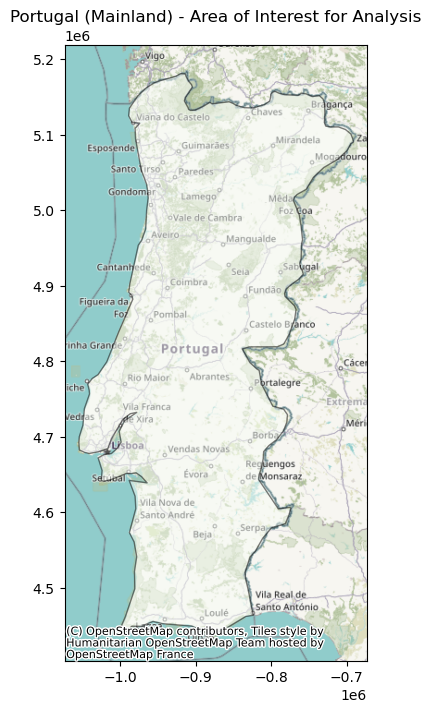

In [7]:
# Load Portugal boundaries from Natural Earth countries dataset
countries_path = "data/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp"
countries = gpd.read_file(countries_path)

# Filter for Latvia from the Natural Earth dataset
portugal_gdf = countries[countries["NAME"] == "Portugal"].copy()
portugal_gdf

if portugal_gdf.empty:
    print("Latvia not found in the Natural Earth dataset. Available countries:")
    print(sorted(countries["NAME"].unique()))
else:
    # Explode MultiPolygon into individual Polygons and keep only the largest (mainland)
    portugal_gdf_exploded = portugal_gdf.explode(index_parts=False).reset_index(
        drop=True
    )

    # Calculate area for each polygon in a projected CRS
    portugal_gdf_exploded_utm = portugal_gdf_exploded.to_crs(epsg=3059)
    portugal_gdf_exploded["area_m2"] = portugal_gdf_exploded_utm.geometry.area

    # Keep only the largest polygon (mainland Portugal)
    largest_idx = portugal_gdf_exploded["area_m2"].idxmax()
    portugal_gdf = portugal_gdf_exploded.loc[[largest_idx]].copy()

    # Project to a suitable projected coordinate system for area calculation (ETRS89 / Latvia TM)
    portugal_gdf_utm = portugal_gdf.to_crs(epsg=3059)  # Latvia TM coordinate system
    portugal_gdf["area_km2"] = (
        portugal_gdf_utm.geometry.area / 1e6
    )  # Convert from m² to km²

    # Keep original area in degrees for compatibility
    portugal_gdf["area"] = portugal_gdf.geometry.area

    # Project to Web Mercator for visualization
    portugal_gdf_proj = portugal_gdf.to_crs(epsg=3857)

    # Visualize Latvia boundaries
    ax = portugal_gdf_proj.plot(
        alpha=0.5, cmap="Greens", edgecolor="k", figsize=(12, 8)
    )
    cx.add_basemap(ax)
    plt.title("Portugal (Mainland) - Area of Interest for Analysis")
    plt.show()

In [8]:
swi_evalscript = """
//VERSION=3
const factor = 1 / 2; // EDIT FACTOR
const offset = 0; // EDIT OFFSET

function setup() {
  return {
    // EDIT VARIABLE NAME
    input: ["SWI002", "dataMask"],
    output: [
      { id: "default", bands: 4, sampleType: "UINT8" },
      { id: "index", bands: 1, sampleType: "FLOAT32" },
      { id: "eobrowserStats", bands: 1, sampleType: "FLOAT32" },
      { id: "dataMask", bands: 1 },
    ],
  };
}

function evaluatePixel(samples) {
  // EDIT VARIABLE NAME
  var originalValue = samples.SWI002;

  let val = originalValue * factor + offset;

  let dataMask = samples.dataMask;

  const indexVal = dataMask === 1 ? val : NaN;
  const imgVals = visualizer.process(val);

  return {
    default: imgVals.concat(dataMask * 255),
    index: [indexVal],
    eobrowserStats: [val],
    dataMask: [dataMask],
  };
}

// EDIT COLOR BAR
const ColorBar = [
  [0.0, [148, 80, 23]],
  [10.0, [172, 118, 47]],
  [20.0, [196, 156, 71]],
  [30.0, [220, 194, 96]],
  [40.0, [245, 233, 121]],
  [50.0, [183, 209, 173]],
  [60.0, [121, 185, 225]],
  [70.0, [97, 152, 203]],
  [80.0, [74, 120, 182]],
  [90.0, [50, 87, 160]],
  [100.0, [27, 55, 139]],
];
const visualizer = new ColorRampVisualizer(ColorBar);
"""

## Request Soil Water Index (SWI) Data for Portugal

Now we'll create a request to fetch SWI data for Portugal using the Process API. We'll use the SWI 2015-present (raster 1 km), Europe, daily – version 1 data collection (BYOC collection ID: bd02588b-7236-4b1e-9480-aeae7dce3c7a).

## Fetch and Visualize NPP Data

Let's fetch the NPP data and create a visualization showing the vegetation coverage across Latvia.

In [46]:
# Create time windows for July of each year
slots = [(f"{year}-08-01", f"{year}-08-31") for year in range(2015, 2025)]

print("August time windows:\n")
for slot in slots:
    print(slot)

August time windows:

('2015-08-01', '2015-08-31')
('2016-08-01', '2016-08-31')
('2017-08-01', '2017-08-31')
('2018-08-01', '2018-08-31')
('2019-08-01', '2019-08-31')
('2020-08-01', '2020-08-31')
('2021-08-01', '2021-08-31')
('2022-08-01', '2022-08-31')
('2023-08-01', '2023-08-31')
('2024-08-01', '2024-08-31')


In [47]:
# Create geometry for Portugal
geometry = Geometry(geometry=portugal_gdf.geometry.values[0], crs=CRS.WGS84)


def get_npp_request(time_interval):
    return SentinelHubRequest(
        evalscript=swi_evalscript,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.define_byoc(
                    "bd02588b-7236-4b1e-9480-aeae7dce3c7a"
                ),
                time_interval=time_interval,
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.PNG)],
        geometry=geometry,
        resolution=[0.01, 0.01],
        config=config,
    )

In [48]:
# create a list of requests
list_of_requests = [get_npp_request(slot) for slot in slots]
list_of_requests = [request.download_list[0] for request in list_of_requests]

# download data with multiple threads
data = SentinelHubDownloadClient(config=config).download(
    list_of_requests, max_threads=5
)

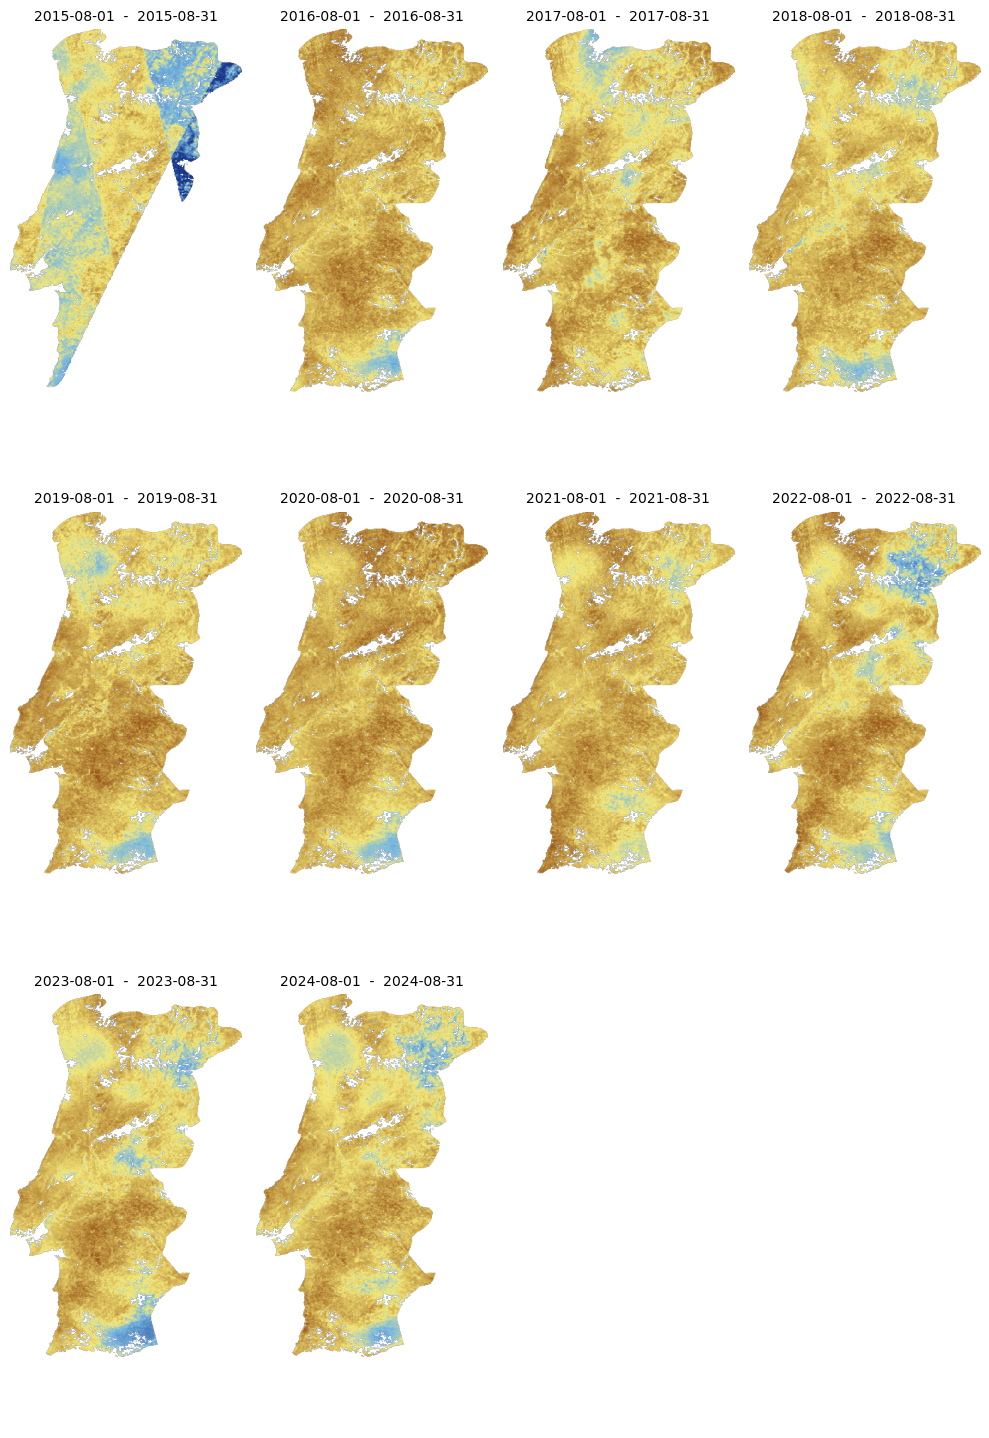

In [49]:
# some stuff for pretty plots
ncols = 4
nrows = 3
aspect_ratio = 0.5 / 1
subplot_kw = {"xticks": [], "yticks": [], "frame_on": False}

fig, axs = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    figsize=(5 * ncols * aspect_ratio, 5 * nrows),
    subplot_kw=subplot_kw,
)

for idx, image in enumerate(data):
    ax = axs[idx // ncols][idx % ncols]
    ax.imshow(np.clip(image))
    ax.set_title(f"{slots[idx][0]}  -  {slots[idx][1]}", fontsize=10)

plt.tight_layout()

## Exercise:

In the example we have run through here, we only use SIMPLE Mosaicking. This means we are only looking at snapshots in time for each of the years in the month of August. However, what if we wanted to find out the minimum or maximum value over the whole summer?

Let's run through together how we can do this together. To help achieve this you can consult this example that calculates [Maximum NDVI](https://custom-scripts.sentinel-hub.com/sentinel-2/max_ndvi/) in the Custom Scripts Repository. If you feel confident you can try and solve it yourself but I will also be creating the example live. 

## Creating multiple time series to compare drought years to the long term means

Finally, we will work together to create a time series analysis of a smaller area of Portugal and compare the SWI in 2022 (a drought year) and the longer term mean.

### Define helper functions to extract statistics from the Statistical API responses

In [58]:
# define functions to extract statistics for all acquisition dates
def extract_stats(date, stat_data):
    d = {}
    for key, value in stat_data["outputs"].items():
        stats = value["bands"]["B0"]["stats"]
        if stats["sampleCount"] == stats["noDataCount"]:
            continue
        else:
            d["date"] = [date]
            for stat_name, stat_value in stats.items():
                if stat_name == "sampleCount" or stat_name == "noDataCount":
                    continue
                else:
                    d[f"{key}_{stat_name}"] = [stat_value]
    return pd.DataFrame(d)


def read_acquisitions_stats(stat_data):
    df_li = []
    for aq in stat_data:
        date = aq["interval"]["from"][:10]
        df_li.append(extract_stats(date, aq))
    return pd.concat(df_li)


def stats_to_df(stats_data):
    """Transform Statistical API response into a pandas.DataFrame"""
    df_data = []

    for single_data in stats_data["data"]:
        df_entry = {}
        is_valid_entry = True

        df_entry["interval_from"] = parse_time(single_data["interval"]["from"]).date()
        df_entry["interval_to"] = parse_time(single_data["interval"]["to"]).date()

        for output_name, output_data in single_data["outputs"].items():
            for band_name, band_values in output_data["bands"].items():
                band_stats = band_values["stats"]
                if band_stats["sampleCount"] == band_stats["noDataCount"]:
                    is_valid_entry = False
                    break

                for stat_name, value in band_stats.items():
                    col_name = f"{output_name}_{band_name}_{stat_name}"
                    if stat_name == "percentiles":
                        for perc, perc_val in value.items():
                            perc_col_name = f"{col_name}_{perc}"
                            df_entry[perc_col_name] = perc_val
                    else:
                        df_entry[col_name] = value

        if is_valid_entry:
            df_data.append(df_entry)

    return pd.DataFrame(df_data)

### Define Study Area: Montemor-o-Novo

We define a bounding box covering the montado-rich area around Montemor-o-Novo in central Alentejo. This region:
- Contains extensive cork oak (*Quercus suber*) woodlands
- Was severely affected by the 2022 drought
- Is representative of the broader Alentejo montado ecosystem

/var/folders/7p/dpt81n653g7cm1ny5rm0_6q80000gn/T/ipykernel_91125/4161063956.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  aoi_gdf["area"] = aoi_gdf.geometry.area


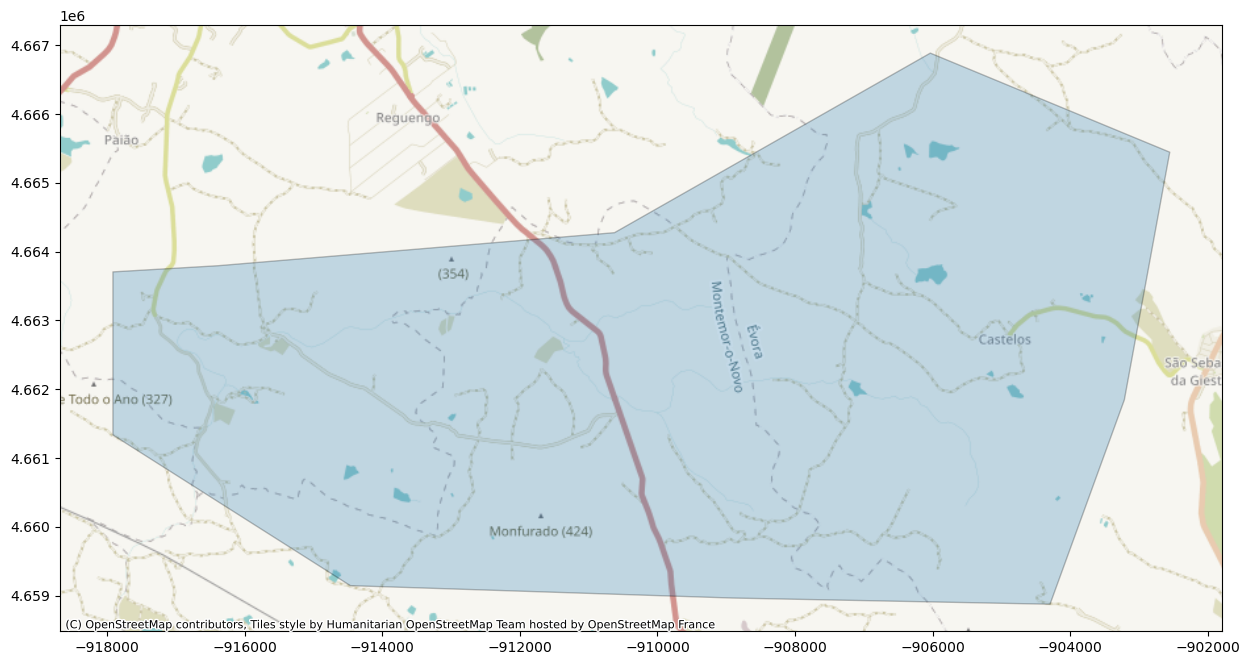

In [52]:
# Load GeoJSON for Montemor-o-Novo forest area
aoi_gdf = gpd.read_file("data/Montemor_forest.geojson")
aoi_gdf["area"] = aoi_gdf.geometry.area

# Get bounds for BBox [west, south, east, north]
montemor_coords = list(aoi_gdf.total_bounds)

# Create BBox and Geometry objects for API requests
montemor_bbox = BBox(bbox=montemor_coords, crs=CRS.WGS84)
montemor_geometry = Geometry(geometry=aoi_gdf.unary_union, crs=CRS.WGS84)

# Visualize the study area
aoi_gdf_wm = aoi_gdf.to_crs(epsg=3857)
ax = aoi_gdf_wm.plot(alpha=0.25, edgecolor="k", figsize=(15, 15))
cx.add_basemap(ax)

### The Evalscript

In this evalscript, we are calculating NDVI. Let's remind ourselves that evalscripts operate slightly differently with Statistical API:

- The `evaluatePixel()` function must, in addition to other output, always return a `dataMask` output. This output defines which pixels are excluded from calculations. For more details and an example, see [here](https://docs.sentinel-hub.com/api/latest/api/statistical/#exclude-pixels-from-calculations-datamask-output).
- The default value of sampleType is `FLOAT32`.
- The output.bands parameter in the setup() function can be an array. This makes it possible to specify custom names for the output bands and different output `dataMask` for different outputs, see this [example](https://docs.sentinel-hub.com/api/latest/api/statistical/examples/#multiple-outputs-with-different-datamasks-multi-band-output-with-custom-bands-names-and-different-histogram-types).

In [55]:
evalscript = """
//VERSION=3
function setup() {
  return {
    input: [{
      bands: [
        "SWI002",
        "dataMask"
      ]
    }],
    output: [
      {
        id: "swi",
        bands: 1
      },
      {
        id: "dataMask",
        bands: 1
      }]
  };
}

function evaluatePixel(samples) {
    return {
        swi: [samples.SWI002],
        dataMask: [samples.dataMask],
    };
}
"""

### The Request Body

Now we have defined the evalscript and the two fields of interest, we can build the first Statistical API Request, before returning the response for the first field. In this request, as part of the payload we define some input parameters:
- `time_interval` this defines the time range of our request.
- `aggregation_interval` this defines the length of time each interval is. In this case, the interval is 10 days. The aggregation intervals should be at least one day long (e.g. "P5D", "P30D"). You can only use period OR time designator not both. 

**NOTE:**
If `time_interval` is not divisible by an aggregationInterval, the last ("not full") time interval will be dismissed by default (SKIP option). The user can instead set the lastIntervalBehavior to SHORTEN (shortens the last interval so that it ends at the end of the provided time range) or EXTEND (extends the last interval over the end of the provided time range so that all the intervals are of equal duration).

In [56]:
aoi_gdf = gpd.read_file("data/Montemor_forest.geojson")

geometry = Geometry(geometry=aoi_gdf.geometry.iloc[0], crs=CRS.WGS84)

request = SentinelHubStatistical(
    aggregation=SentinelHubStatistical.aggregation(
        evalscript=evalscript,
        time_interval=("2022-01-01T00:00:00Z", "2022-12-31T23:59:59Z"),
        aggregation_interval="P5D",
        resolution=(0.001, 0.001),
    ),
    input_data=[
        SentinelHubStatistical.input_data(
            data_collection=DataCollection.define_byoc(
                "bd02588b-7236-4b1e-9480-aeae7dce3c7a"
            ),
        ),
    ],
    geometry=geometry,
    config=config,
)

response1 = request.get_data()
# response1 # try uncommenting this line to see what the raw JSON response looks like.

### Manipulation and Visualisation of our Output

However, as it is clear to see, our response is not that useful in `json` format. It's difficult to read from a human perspective. So, let's transform it into a `pandas` dataframe. To help us achieve this, let's call some helper functions. 

In [59]:
result_df1 = read_acquisitions_stats(response1[0]["data"])
result_df1

,date,swi_min,swi_max,swi_mean,swi_stDev
0,2022-01-01,157.0,168.0,162.604291,2.792571
0,2022-01-06,144.0,155.0,149.683209,2.611688
0,2022-01-11,130.0,152.0,138.780224,3.807032
0,2022-01-16,111.0,136.0,120.473321,5.748332
0,2022-01-21,95.0,136.0,109.533955,6.024698
...,...,...,...,...,...
0,2022-12-02,167.0,184.0,175.347575,3.836963
0,2022-12-07,186.0,191.0,188.261567,1.247332
0,2022-12-12,190.0,192.0,191.853731,0.354430
0,2022-12-17,191.0,197.0,196.620522,0.899642


We can take this another step further, and display the data in a time series using the Matplotlib python library:

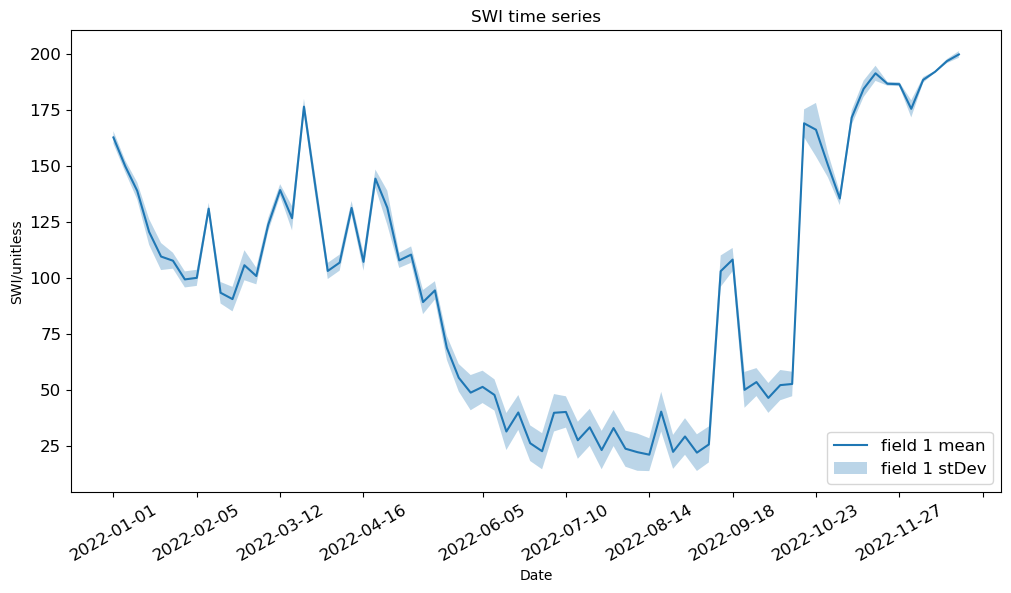

In [62]:
fig_stat, ax_stat = plt.subplots(1, 1, figsize=(12, 6))

# Extract data
t1 = result_df1["date"]
swi_mean_field1 = result_df1["swi_mean"]
swi_std_field1 = result_df1["swi_stDev"]

# Plot mean and standard deviation
ax_stat.plot(t1, swi_mean_field1, label="field 1 mean")
ax_stat.fill_between(
    t1,
    swi_mean_field1 - swi_std_field1,
    swi_mean_field1 + swi_std_field1,
    alpha=0.3,
    label="field 1 stDev",
)

# Set tick parameters
ax_stat.tick_params(axis="x", labelrotation=30, labelsize=12)
ax_stat.tick_params(axis="y", labelsize=12)

# Reduce number of x-tick labels
ax_stat.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=20))

# Set labels and title
ax_stat.set(xlabel="Date", ylabel="SWI/unitless", title="SWI time series")

# Set legend
ax_stat.legend(loc="lower right", prop={"size": 12});

TODO:

add in other years
Final exercise in second notebook - tell your own story with CLMS data and Sentinel data using images and or time series


## Multi-year Statistical Analysis

Loop through years 2015-2024 to collect statistical data for each year.

In [63]:
# Loop through years 2015-2024 and collect responses
aoi_gdf = gpd.read_file("data/Montemor_forest.geojson")
geometry = Geometry(geometry=aoi_gdf.geometry.iloc[0], crs=CRS.WGS84)

all_responses = {}

for year in range(2015, 2025):
    print(f"Fetching data for {year}...")

    request = SentinelHubStatistical(
        aggregation=SentinelHubStatistical.aggregation(
            evalscript=evalscript,
            time_interval=(f"{year}-01-01T00:00:00Z", f"{year}-12-31T23:59:59Z"),
            aggregation_interval="P5D",
            resolution=(0.001, 0.001),
        ),
        input_data=[
            SentinelHubStatistical.input_data(
                data_collection=DataCollection.define_byoc(
                    "bd02588b-7236-4b1e-9480-aeae7dce3c7a"
                ),
            ),
        ],
        geometry=geometry,
        config=config,
    )

    all_responses[year] = request.get_data()

print(f"\nCollected data for {len(all_responses)} years")

Fetching data for 2015...
Fetching data for 2016...
Fetching data for 2017...
Fetching data for 2018...
Fetching data for 2019...
Fetching data for 2020...
Fetching data for 2021...
Fetching data for 2022...
Fetching data for 2023...
Fetching data for 2024...

Collected data for 10 years


In [65]:
# View the collected responses
for year, response in all_responses.items():
    n_intervals = (
        len(response[0]["data"]) if response and response[0].get("data") else 0
    )
    print(f"{year}: {n_intervals} time intervals")

2015: 72 time intervals
2016: 73 time intervals
2017: 72 time intervals
2018: 72 time intervals
2019: 72 time intervals
2020: 73 time intervals
2021: 72 time intervals
2022: 72 time intervals
2023: 72 time intervals
2024: 73 time intervals


In [66]:
# Convert all responses to DataFrames
all_dfs = {}
for year, response in all_responses.items():
    if response and response[0].get("data"):
        df = read_acquisitions_stats(response[0]["data"])
        df["date"] = pd.to_datetime(df["date"])
        df["day_of_year"] = df["date"].dt.dayofyear
        all_dfs[year] = df

print(f"Converted {len(all_dfs)} years to DataFrames")

Converted 10 years to DataFrames


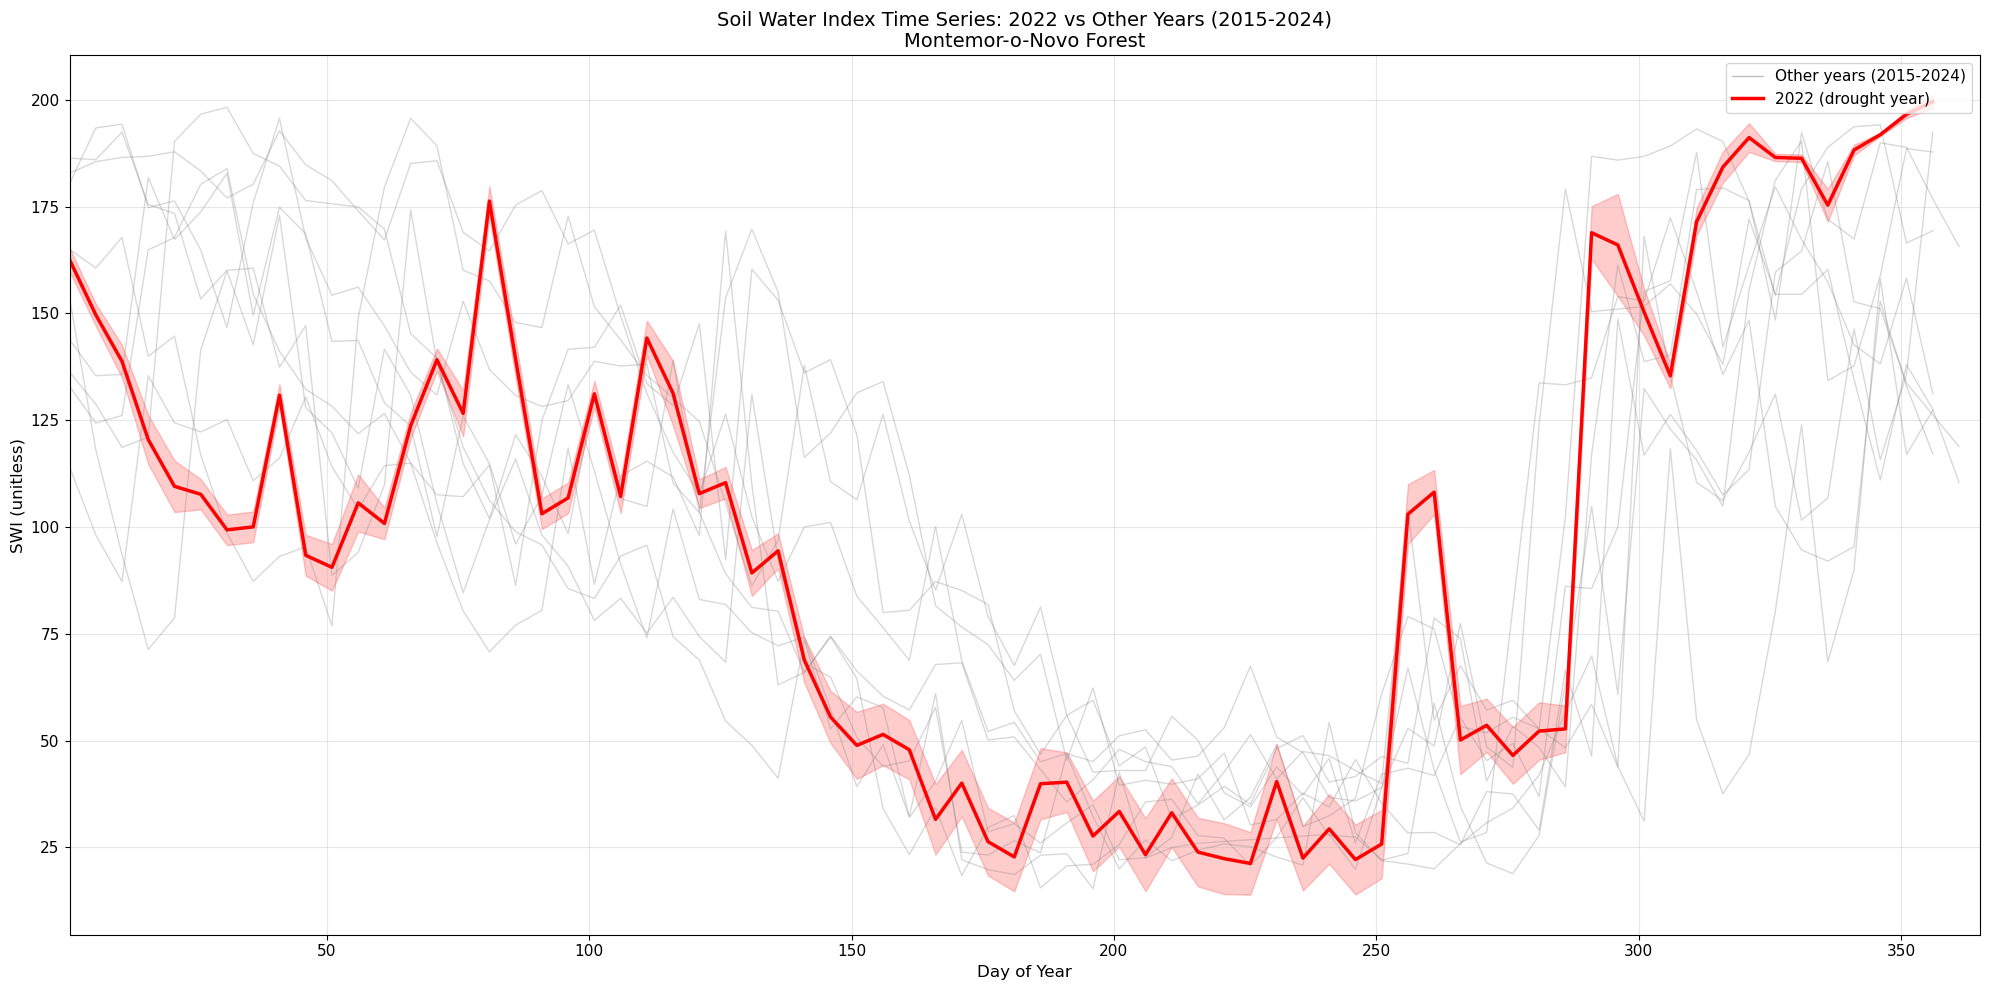

In [68]:
# Plot multi-year SWI time series with 2022 highlighted
fig, ax = plt.subplots(figsize=(20, 10))

# Plot background years (not 2022) in gray
for year, df in all_dfs.items():
    if year != 2022:
        ax.plot(
            df["day_of_year"],
            df["swi_mean"],
            color="gray",
            alpha=0.3,
            linewidth=1,
            label=f"{year}" if year == 2015 else "",
        )

# Plot 2022 prominently
if 2022 in all_dfs:
    df_2022 = all_dfs[2022]
    ax.plot(
        df_2022["day_of_year"],
        df_2022["swi_mean"],
        color="red",
        linewidth=2.5,
        label="2022 (drought year)",
    )
    ax.fill_between(
        df_2022["day_of_year"],
        df_2022["swi_mean"] - df_2022["swi_stDev"],
        df_2022["swi_mean"] + df_2022["swi_stDev"],
        color="red",
        alpha=0.2,
    )

# Formatting
ax.set_xlabel("Day of Year", fontsize=12)
ax.set_ylabel("SWI (unitless)", fontsize=12)
ax.set_title(
    "Soil Water Index Time Series: 2022 vs Other Years (2015-2024)\nMontemor-o-Novo Forest",
    fontsize=14,
)
ax.set_xlim(1, 365)
ax.tick_params(axis="both", labelsize=11)

# Custom legend
from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0], [0], color="gray", alpha=0.5, linewidth=1, label="Other years (2015-2024)"
    ),
    Line2D([0], [0], color="red", linewidth=2.5, label="2022 (drought year)"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=11)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Key findings:**
The time series visualization does show the 2022 drought impact on soil moisture in the Montemor-o-Novo montado ecosystem, with SWI values deviating from the historical range observed in other years.

### Final Exercise

Using all that you have learnt I want you now to tell your own story either using CLMS or Sentinel data. You can do this visually with the imagery / data in map format and/or create statistical plots like a time series. You can even combine them into a single visualisation.

## Summary

This notebook demonstrated how to use the Sentinel Hub Statistical API to analyze Soil Water Index (SWI) data for the Montemor-o-Novo forest region in Portugal's Alentejo.

**Key steps covered:**
1. **Study area definition** - Loaded the Montemor-o-Novo forest boundary from a GeoJSON file
2. **Evalscript creation** - Defined an evalscript to extract SWI data from CLMS BYOC collection
3. **Statistical API requests** - Retrieved aggregated SWI statistics over defined time intervals
4. **Visualising your request responses**
5. **Multi-year analysis** - Collected data from 2015-2024 and created a comparative visualization highlighting 2022 (drought year) against historical context